# NB09b — M18 Amplification Gate Test (Phase 2 KO)

**Project**: Gene Function Ecological Agora — Innovation Atlas Across the Bacterial Tree  
**Phase**: 2 — Functional Resolution (KO, paralog-explicit)  
**Purpose**: Test whether KO aggregation amplifies the Sankoff parsimony Cohen's d signal from the UniRef50 baseline (d = 0.146 in NB08c) to the M18 hard threshold (d ≥ 0.3) for at least one positive HGT control class vs negative housekeeping. This is a **falsification gate**, not a validated prediction. PASS → NB10 full atlas; FAIL → halt for M11 redesign (gene-tree-vs-species-tree reconciliation per AleRax sub-sampling).

## Methodology Commitments

- **M16** Sankoff parsimony on the GTDB-r214 tree topology is the primary atlas metric. Per-leaf Sankoff (`gain_events / n_present_leaves`) is the comparison statistic.
- **M17** AMR is excluded from the positive-control panel (Pseudomonadota detection bias documented in NB08c Diagnostic D). Positive controls are β-lactamase, class-I CRISPR-Cas, TCS HK; negative housekeeping is ribosomal, tRNA-synth, RNAP core.
- **M18** Hard amplification gate: PASS if any (positive HGT control class, negative housekeeping class) pair achieves Cohen's d ≥ 0.3 on Sankoff/n_present with 95% bootstrap CI lower bound > 0.
- **M19** Cluster-bootstrap for Cohen's d 95% CIs. At KO level, the natural unit is the KO itself (function-aggregated; intra-Pfam-family UniRef duplication is collapsed by the projection). Bootstrap KOs within control class with replacement (B = 200). The Pfam-family-granularity cluster-bootstrap that M19 specifies for UniRef-level inference reduces to KO-level bootstrap once aggregation collapses the intra-family duplicates.

## Inputs

- `data/p2_ko_assignments_panel.parquet` — control-panel subset of (species, KO) presence (from NB09 Stage 12). The full atlas at `s3a://.../p2_ko_assignments.parquet` is 28M rows; the panel subset is 2.69M rows × 7.8 MB and fits driver-side.
- `data/p2_ko_control_classes.tsv` — KO → control class assignment (from NB09).
- `data/p1b_full_species.tsv` — species set with `representative_genome_id` for tree-leaf mapping.
- `user_data/bac120_r214.tree` — GTDB r214 species tree (newick). Same tree used by NB08c.

## Outputs

- `data/p2_m18_sankoff_per_ko.tsv` — per-KO Sankoff parsimony score for control panel.
- `data/p2_m18_class_summary.tsv` — per-class median/mean/quantiles on score_per_present.
- `data/p2_m18_cohens_d_pairs.tsv` — pairwise (pos, neg) Cohen's d with M19 bootstrap CIs.
- `data/p2_m18_gate_decision.json` — gate verdict + diagnostics + decision log.
- `figures/p2_m18_amplification_panel.png` — companion figure to NB08c Diagnostic C.

## Setup + load inputs

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora")
DATA_DIR = PROJECT_ROOT / "data"
USER_DATA = PROJECT_ROOT / "user_data"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

diagnostics = {
    "phase": "2",
    "notebook": "NB09b",
    "gate": "M18",
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "d_threshold": 0.30,
    "uniref50_baseline_d": 0.146,
    "bootstrap_B": 200,
}

# NB09 Stage 12 wrote p2_ko_assignments_panel.parquet — control-panel subset only,
# filtered from the full 28M-row p2_ko_assignments parquet on MinIO.
ko_assign = pd.read_parquet(DATA_DIR / "p2_ko_assignments_panel.parquet")
ko_class = pd.read_csv(DATA_DIR / "p2_ko_control_classes.tsv", sep="\t")
species = pd.read_csv(DATA_DIR / "p1b_full_species.tsv", sep="\t")
print(f"KO assignments (panel): {len(ko_assign):,} rows")
print(f"KO control classes: {len(ko_class):,} rows | classes: {ko_class['control_class'].value_counts().to_dict()}")
print(f"P1B species: {len(species):,} rows")

KO assignments (panel): 2,687,345 rows
KO control classes: 13,062 rows | classes: {'none': 12279, 'pos_tcs_hk': 310, 'neg_ribosomal': 249, 'pos_betalac': 110, 'neg_trna_synth': 54, 'info_amr': 35, 'neg_rnap_core': 19, 'pos_crispr_cas': 6}
P1B species: 18,989 rows


## Subset to control panel KOs

In [2]:
POS_CLASSES = ["pos_betalac", "pos_crispr_cas", "pos_tcs_hk"]
NEG_CLASSES = ["neg_ribosomal", "neg_trna_synth", "neg_rnap_core"]
PANEL_CLASSES = POS_CLASSES + NEG_CLASSES

panel_kos = ko_class[ko_class["control_class"].isin(PANEL_CLASSES)][["ko", "control_class", "n_clusters_total"]].copy()
diagnostics["panel_class_ko_counts"] = panel_kos["control_class"].value_counts().to_dict()
print("Control panel KO counts:")
print(json.dumps(diagnostics["panel_class_ko_counts"], indent=2, default=str))

# Restrict assignments to panel KOs and present rows
panel_assign = ko_assign[ko_assign["ko"].isin(panel_kos["ko"]) & ko_assign["is_present"]].copy()
diagnostics["panel_assignments_n"] = int(len(panel_assign))
print(f"Panel (species, KO) present rows: {len(panel_assign):,}")

Control panel KO counts:
{
  "pos_tcs_hk": 310,
  "neg_ribosomal": 249,
  "pos_betalac": 110,
  "neg_trna_synth": 54,
  "neg_rnap_core": 19,
  "pos_crispr_cas": 6
}
Panel (species, KO) present rows: 2,687,345


## Map species_clade_id → representative_genome_id (tree leaf)

In [3]:
clade_to_rep = dict(zip(species["gtdb_species_clade_id"], species["representative_genome_id"]))
rep_ids_set = set(species["representative_genome_id"].dropna().tolist())
diagnostics["n_reps_p1b"] = len(rep_ids_set)
print(f"P1B representative genomes (target tree leaves): {len(rep_ids_set):,}")

P1B representative genomes (target tree leaves): 18,989


## Parse + prune GTDB-r214 tree (reused verbatim from NB08c)

In [4]:
tree_path = USER_DATA / "bac120_r214.tree"

class Node:
    __slots__ = ("name", "children", "parent")
    def __init__(self, name="", children=None, parent=None):
        self.name = name
        self.children = children if children is not None else []
        self.parent = parent
    def is_leaf(self):
        return not self.children

def parse_newick(s):
    pos = [0]
    def skip_ws():
        while pos[0] < len(s) and s[pos[0]].isspace():
            pos[0] += 1
    def parse_node(parent=None):
        skip_ws()
        children = []
        if pos[0] < len(s) and s[pos[0]] == "(":
            pos[0] += 1
            children.append(parse_node())
            skip_ws()
            while pos[0] < len(s) and s[pos[0]] == ",":
                pos[0] += 1
                children.append(parse_node())
                skip_ws()
            assert s[pos[0]] == ")", f"Expected ) at {pos[0]}"
            pos[0] += 1
        skip_ws()
        name_start = pos[0]
        if pos[0] < len(s) and s[pos[0]] == "'":
            pos[0] += 1
            while pos[0] < len(s) and s[pos[0]] != "'":
                pos[0] += 1
            if pos[0] < len(s):
                pos[0] += 1
        while pos[0] < len(s) and s[pos[0]] not in ",();":
            pos[0] += 1
        token = s[name_start:pos[0]]
        if token.startswith("'") and "'" in token[1:]:
            name_part = token[1:token.find("'", 1)]
        else:
            name_part = token.split(":")[0].strip().strip("'")
        node = Node(name=name_part, children=children, parent=parent)
        for c in children:
            c.parent = node
        return node
    return parse_node()

print(f"Loading {tree_path.name} ({tree_path.stat().st_size / 1e6:.1f} MB)...")
with open(tree_path) as f:
    newick_text = f.read()
t0 = time.time()
tree = parse_newick(newick_text)
all_leaves = []
def _collect(node, out):
    if node.is_leaf():
        out.append(node)
    else:
        for c in node.children:
            _collect(c, out)
_collect(tree, all_leaves)
print(f"Parsed in {time.time()-t0:.1f}s. Full tree: {len(all_leaves):,} leaves")
diagnostics["tree_n_leaves_full"] = len(all_leaves)

def prune_tree(node, keep_set):
    if node.is_leaf():
        return node if node.name in keep_set else None
    kept = [prune_tree(c, keep_set) for c in node.children]
    kept = [c for c in kept if c is not None]
    if not kept:
        return None
    if len(kept) == 1:
        return kept[0]
    node.children = kept
    for c in kept:
        c.parent = node
    return node

t0 = time.time()
tree = prune_tree(tree, rep_ids_set)
pruned_leaves = []
_collect(tree, pruned_leaves)
print(f"Pruned in {time.time()-t0:.1f}s. Pruned tree: {len(pruned_leaves):,} leaves")
diagnostics["tree_n_leaves_pruned"] = len(pruned_leaves)

def postorder(root):
    out = []
    stack = [(root, False)]
    while stack:
        node, visited = stack.pop()
        if visited:
            out.append(node)
        else:
            stack.append((node, True))
            for child in node.children:
                stack.append((child, False))
    return out

postorder_list = postorder(tree)
print(f"Post-order list: {len(postorder_list):,} nodes")

Loading bac120_r214.tree (4.2 MB)...


Parsed in 0.8s. Full tree: 80,789 leaves
Pruned in 0.0s. Pruned tree: 18,989 leaves
Post-order list: 37,977 nodes


## Build (KO → set of present reps) and compute Sankoff parsimony

In [5]:
def fitch_parsimony_score(postorder_nodes, present_leaves_set):
    """Fitch binary-trait parsimony: minimum independent gains assuming root absent."""
    states = {}
    union_count = 0
    for node in postorder_nodes:
        if node.is_leaf():
            states[id(node)] = 1 if node.name in present_leaves_set else 0
        else:
            child_states = set(states[id(c)] for c in node.children)
            if len(child_states) == 1:
                states[id(node)] = next(iter(child_states))
            else:
                states[id(node)] = 2
                union_count += 1
    return union_count

panel_assign["rep_id"] = panel_assign["gtdb_species_clade_id"].map(clade_to_rep)
ko_to_present_reps = panel_assign.groupby("ko")["rep_id"].apply(set).to_dict()
diagnostics["n_panel_kos_to_score"] = len(ko_to_present_reps)

ko_class_lookup = dict(zip(panel_kos["ko"], panel_kos["control_class"]))

print(f"Computing Sankoff parsimony on {len(ko_to_present_reps)} panel KOs...")
t0 = time.time()
rows = []
n_done = 0
for ko, present in ko_to_present_reps.items():
    present_in_tree = present & rep_ids_set
    n_present = len(present_in_tree)
    if n_present == 0:
        continue
    score = fitch_parsimony_score(postorder_list, present_in_tree)
    rows.append({
        "ko": ko,
        "control_class": ko_class_lookup[ko],
        "n_present_leaves": n_present,
        "sankoff_parsimony_score": int(score),
        "score_per_present": round(score / n_present, 4) if n_present > 0 else np.nan,
    })
    n_done += 1
    if n_done % 200 == 0:
        elapsed = time.time() - t0
        rate = n_done / elapsed
        eta = (len(ko_to_present_reps) - n_done) / rate
        print(f"  {n_done}/{len(ko_to_present_reps)} ({rate:.1f} KO/s, ETA {eta:.0f}s)")

sankoff_df = pd.DataFrame(rows)
elapsed = time.time() - t0
diagnostics["sankoff_n_scored"] = int(len(sankoff_df))
diagnostics["sankoff_elapsed_s"] = round(elapsed, 1)
print(f"\nSankoff complete in {elapsed:.1f}s ({len(sankoff_df)} KOs scored)")

sankoff_df.to_csv(DATA_DIR / "p2_m18_sankoff_per_ko.tsv", sep="\t", index=False)
print(f"Wrote p2_m18_sankoff_per_ko.tsv")

Computing Sankoff parsimony on 748 panel KOs...


  200/748 (66.3 KO/s, ETA 8s)


  400/748 (67.3 KO/s, ETA 5s)


  600/748 (68.3 KO/s, ETA 2s)



Sankoff complete in 11.0s (748 KOs scored)
Wrote p2_m18_sankoff_per_ko.tsv


## Per-class summary

In [6]:
summary_rows = []
for cls, sub in sankoff_df.groupby("control_class"):
    summary_rows.append({
        "control_class": cls,
        "n": len(sub),
        "median_score": round(sub["sankoff_parsimony_score"].median(), 1),
        "mean_score": round(sub["sankoff_parsimony_score"].mean(), 1),
        "median_score_per_present": round(sub["score_per_present"].median(), 4),
        "mean_score_per_present": round(sub["score_per_present"].mean(), 4),
        "q25_spp": round(sub["score_per_present"].quantile(0.25), 4),
        "q75_spp": round(sub["score_per_present"].quantile(0.75), 4),
    })
class_summary = pd.DataFrame(summary_rows).sort_values("median_score_per_present", ascending=False)
class_summary.to_csv(DATA_DIR / "p2_m18_class_summary.tsv", sep="\t", index=False)
print("=== Per-class Sankoff parsimony summary ===")
print("(higher score_per_present = more independent gains = HGT-like)")
print()
print(class_summary.to_string(index=False))

=== Per-class Sankoff parsimony summary ===
(higher score_per_present = more independent gains = HGT-like)

 control_class   n  median_score  mean_score  median_score_per_present  mean_score_per_present  q25_spp  q75_spp
 neg_rnap_core  19         303.0       603.0                   14.5000                 15.6264   9.3286  20.0000
 neg_ribosomal 249         327.0       938.9                   11.3452                 12.9500   0.1374  23.2727
   pos_betalac 110         955.0      1263.6                    2.6380                  5.3624   0.7408   5.7168
pos_crispr_cas   6        3163.5      3483.0                    2.0406                  2.4325   1.8665   2.3368
    pos_tcs_hk 310        1411.0      1671.3                    1.4697                  2.4262   0.9610   2.3256
neg_trna_synth  54         678.5      1069.5                    0.3017                  3.9066   0.0345   6.9594


## Pairwise Cohen's d with M19 cluster-bootstrap CIs

In [7]:
def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_sd = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    if pooled_sd == 0:
        return 0.0
    return (a.mean() - b.mean()) / pooled_sd

def bootstrap_d_ci(a_vals, b_vals, B=200, alpha=0.05, seed=42):
    """M19 cluster-bootstrap on KOs within control class. Returns (point, lower, upper)."""
    rng = np.random.default_rng(seed)
    n_a, n_b = len(a_vals), len(b_vals)
    if n_a < 2 or n_b < 2:
        return (np.nan, np.nan, np.nan)
    point = cohens_d(a_vals, b_vals)
    boots = np.empty(B)
    a_arr = np.asarray(a_vals)
    b_arr = np.asarray(b_vals)
    for i in range(B):
        a_resample = rng.choice(a_arr, size=n_a, replace=True)
        b_resample = rng.choice(b_arr, size=n_b, replace=True)
        boots[i] = cohens_d(a_resample, b_resample)
    lower = np.quantile(boots, alpha / 2)
    upper = np.quantile(boots, 1 - alpha / 2)
    return (point, lower, upper)

B = diagnostics["bootstrap_B"]
pair_rows = []
for pos_class in POS_CLASSES:
    pos_vals = sankoff_df[sankoff_df["control_class"] == pos_class]["score_per_present"].dropna().values
    for neg_class in NEG_CLASSES:
        neg_vals = sankoff_df[sankoff_df["control_class"] == neg_class]["score_per_present"].dropna().values
        d, ci_lo, ci_hi = bootstrap_d_ci(pos_vals, neg_vals, B=B, seed=RNG_SEED)
        # Mann-Whitney one-sided greater (HGT > housekeeping is the predicted direction)
        if len(pos_vals) >= 2 and len(neg_vals) >= 2:
            u_stat, mw_p = stats.mannwhitneyu(pos_vals, neg_vals, alternative="greater")
        else:
            u_stat, mw_p = (np.nan, np.nan)
        pair_rows.append({
            "positive_class": pos_class,
            "negative_class": neg_class,
            "n_pos": len(pos_vals),
            "n_neg": len(neg_vals),
            "cohens_d": round(d, 4) if not np.isnan(d) else np.nan,
            "d_ci_lower": round(ci_lo, 4) if not np.isnan(ci_lo) else np.nan,
            "d_ci_upper": round(ci_hi, 4) if not np.isnan(ci_hi) else np.nan,
            "mannwhitney_p_greater": round(mw_p, 6) if not np.isnan(mw_p) else np.nan,
            "meets_d_threshold": (not np.isnan(d)) and (d >= 0.30) and (ci_lo > 0),
        })
pairs_df = pd.DataFrame(pair_rows)
pairs_df.to_csv(DATA_DIR / "p2_m18_cohens_d_pairs.tsv", sep="\t", index=False)
print("=== Pairwise Cohen's d (positive HGT vs negative housekeeping) ===")
print("(M19: 95% bootstrap CI on B=200 KO-level resamples within class)")
print()
print(pairs_df.to_string(index=False))

=== Pairwise Cohen's d (positive HGT vs negative housekeeping) ===
(M19: 95% bootstrap CI on B=200 KO-level resamples within class)

positive_class negative_class  n_pos  n_neg  cohens_d  d_ci_lower  d_ci_upper  mannwhitney_p_greater  meets_d_threshold
   pos_betalac  neg_ribosomal    110    249   -0.6593     -0.8122     -0.4865               0.975055              False
   pos_betalac neg_trna_synth    110     54    0.2118     -0.1382      0.5315               0.000011              False
   pos_betalac  neg_rnap_core    110     19   -1.2907     -2.1588     -0.6556               0.999402              False
pos_crispr_cas  neg_ribosomal      6    249   -0.8181     -0.9676     -0.6807               0.732031              False
pos_crispr_cas neg_trna_synth      6     54   -0.2405     -0.4779      0.1158               0.056814              False
pos_crispr_cas  neg_rnap_core      6     19   -1.2510     -1.9681     -0.8767               0.985940              False
    pos_tcs_hk  neg_ribosom

## M18 gate verdict

In [8]:
passing_pairs = pairs_df[pairs_df["meets_d_threshold"]]
n_passing = len(passing_pairs)
best_pair = pairs_df.loc[pairs_df["cohens_d"].idxmax()] if len(pairs_df) > 0 else None

diagnostics["n_passing_pairs"] = int(n_passing)
diagnostics["best_pair"] = (
    {
        "positive_class": str(best_pair["positive_class"]),
        "negative_class": str(best_pair["negative_class"]),
        "cohens_d": float(best_pair["cohens_d"]),
        "d_ci_lower": float(best_pair["d_ci_lower"]),
        "d_ci_upper": float(best_pair["d_ci_upper"]),
        "mannwhitney_p_greater": float(best_pair["mannwhitney_p_greater"]),
    } if best_pair is not None else None
)

if n_passing >= 1:
    verdict = "PASS"
    decision = "M18 amplification gate PASS — KO aggregation amplifies Sankoff Cohen's d to ≥ 0.3 with 95% CI lower bound > 0 for at least one positive HGT control class vs negative housekeeping. Proceed to NB10 (full KO atlas)."
elif best_pair is not None and best_pair["cohens_d"] >= 0.20:
    verdict = "MARGINAL"
    decision = (
        f"M18 amplification gate MARGINAL — best pair ({best_pair['positive_class']} vs {best_pair['negative_class']}) "
        f"shows Cohen's d = {best_pair['cohens_d']} with 95% CI [{best_pair['d_ci_lower']}, {best_pair['d_ci_upper']}]. "
        "Below the d ≥ 0.3 hard threshold but above the UniRef50 baseline (d = 0.146); aggregation produces partial amplification. "
        "Decision deferred to user: proceed cautiously with NB10 atlas treating substrate-hierarchy claim as weakened, or halt for M11 redesign."
    )
else:
    verdict = "FAIL"
    decision = (
        f"M18 amplification gate FAIL — no positive×negative pair achieves Cohen's d ≥ 0.3 with 95% CI lower bound > 0. "
        f"Best pair: Cohen's d = {best_pair['cohens_d'] if best_pair is not None else 'N/A'}. "
        "Substrate-hierarchy claim falsified at KO resolution. M11 redesign triggers: switch from Sankoff parsimony to gene-tree-vs-species-tree reconciliation "
        "(per AleRax sub-sampling, plan v2.6 reservation). Halt Phase 2 atlas; do NOT proceed to NB10."
    )

diagnostics["verdict"] = verdict
diagnostics["decision"] = decision
print(f"\n*** M18 GATE VERDICT: {verdict} ***\n")
print(decision)


*** M18 GATE VERDICT: MARGINAL ***

M18 amplification gate MARGINAL — best pair (pos_betalac vs neg_trna_synth) shows Cohen's d = 0.2118 with 95% CI [-0.1382, 0.5315]. Below the d ≥ 0.3 hard threshold but above the UniRef50 baseline (d = 0.146); aggregation produces partial amplification. Decision deferred to user: proceed cautiously with NB10 atlas treating substrate-hierarchy claim as weakened, or halt for M11 redesign.


## Figure — KO-level Sankoff parsimony per class (companion to NB08c Diagnostic C)

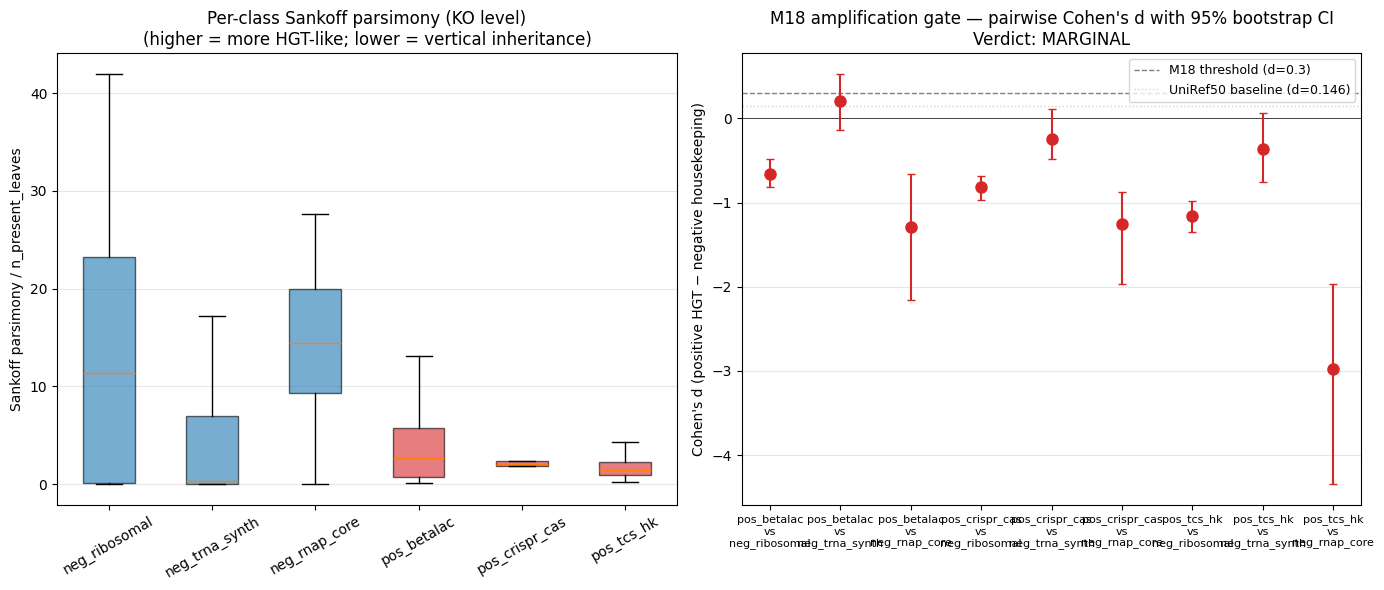

Wrote /home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora/figures/p2_m18_amplification_panel.png


In [9]:
control_order = NEG_CLASSES + POS_CLASSES
color_map = {
    "neg_ribosomal": "#1f77b4",
    "neg_trna_synth": "#1f77b4",
    "neg_rnap_core": "#1f77b4",
    "pos_betalac": "#d62728",
    "pos_crispr_cas": "#d62728",
    "pos_tcs_hk": "#d62728",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A — boxplot of score_per_present per class
data_by_class = [sankoff_df[sankoff_df["control_class"] == c]["score_per_present"].values for c in control_order if c in sankoff_df["control_class"].unique()]
labels = [c for c in control_order if c in sankoff_df["control_class"].unique()]
colors = [color_map[c] for c in labels]
bp = axes[0].boxplot(data_by_class, tick_labels=labels, showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel("Sankoff parsimony / n_present_leaves")
axes[0].set_title("Per-class Sankoff parsimony (KO level)\n(higher = more HGT-like; lower = vertical inheritance)")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis="y", alpha=0.3)

# Panel B — Cohen's d per (pos, neg) pair with bootstrap CIs
axes[1].axhline(y=0.30, color='gray', linestyle='--', linewidth=1, label='M18 threshold (d=0.3)')
axes[1].axhline(y=0.146, color='lightgray', linestyle=':', linewidth=1, label='UniRef50 baseline (d=0.146)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
x_positions = np.arange(len(pairs_df))
axes[1].errorbar(
    x_positions, pairs_df["cohens_d"],
    yerr=[pairs_df["cohens_d"] - pairs_df["d_ci_lower"], pairs_df["d_ci_upper"] - pairs_df["cohens_d"]],
    fmt='o', capsize=3, color='#d62728', markersize=8,
)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels([f"{r['positive_class']}\nvs\n{r['negative_class']}" for _, r in pairs_df.iterrows()], rotation=0, fontsize=8)
axes[1].set_ylabel("Cohen's d (positive HGT − negative housekeeping)")
axes[1].set_title(f"M18 amplification gate — pairwise Cohen's d with 95% bootstrap CI\nVerdict: {verdict}")
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
fig_path = FIG_DIR / "p2_m18_amplification_panel.png"
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Wrote {fig_path}")

## Persist gate decision

In [10]:
diagnostics["completed_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
with open(DATA_DIR / "p2_m18_gate_decision.json", "w") as f:
    json.dump(diagnostics, f, indent=2, default=str)
print("Wrote p2_m18_gate_decision.json")
print("\n=== Decision summary ===")
print(f"Verdict: {diagnostics['verdict']}")
print(f"Best pair: {diagnostics.get('best_pair', {})}")
print(f"Number of passing pairs: {diagnostics['n_passing_pairs']} / {len(pairs_df)}")

Wrote p2_m18_gate_decision.json

=== Decision summary ===
Verdict: MARGINAL
Best pair: {'positive_class': 'pos_betalac', 'negative_class': 'neg_trna_synth', 'cohens_d': 0.2118, 'd_ci_lower': -0.1382, 'd_ci_upper': 0.5315, 'mannwhitney_p_greater': 1.1e-05}
Number of passing pairs: 0 / 9
